<a href="https://colab.research.google.com/github/christinengalle19-collab/Assignement2New/blob/main/Assignment14ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fairlearn
!pip install lime

In [ ]:
#import necessary libraries
import io
import requests
from google.colab import files
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from fairlearn.metrics import MetricFrame, selection_rate, false_positive_rate, true_positive_rate
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import shap
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import joblib
import warnings
import os

# Suppress warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
#Load the dataset
column_names = ['Age', 'Workclass', 'fnlwgt', 'education', 'edu_num', 'marital_status', 'occupation', 'relatioship', 'race', 'Gender', 'Capital_gain', 'capital_loss', 'hours', 'country', 'Salary']
# Explicitly set 'Salary' column to be read as string to prevent incorrect type inference.
df = pd.read_csv('adult.csv', header=None, names=column_names, dtype={'Salary': str})

# Strip whitespace from object columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

In [ ]:
#display first rows
df.head()

,Age,Workclass,fnlwgt,education,edu_num,marital_status,occupation,relatioship,race,Gender,Capital_gain,capital_loss,hours,country,Salary
0,Age,Workclass,fnlwgt,education,edu_num,marital_status,occupation,relatioship,race,Gender,Capital_gain,capital_loss,hours,country,Salary
1,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
2,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
3,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
4,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K


In [ ]:
#check for missing values
print(df.isnull().sum())


Age               0
Workclass         0
fnlwgt            0
education         0
edu_num           0
marital_status    0
occupation        0
relatioship       0
race              0
Gender            0
Capital_gain      0
capital_loss      0
hours             0
country           0
Salary            0
dtype: int64


In [ ]:
#data types
print(df.dtypes)

Age               object
Workclass         object
fnlwgt            object
education         object
edu_num           object
marital_status    object
occupation        object
relatioship       object
race              object
Gender            object
Capital_gain      object
capital_loss      object
hours             object
country           object
Salary            object
dtype: object


In [ ]:
#Basics statistics description
print(df.describe())

          Age Workclass  fnlwgt education edu_num      marital_status  \
count   32562     32562   32562     32562   32562               32562   
unique     74        10   21649        17      17                   8   
top        36   Private  203488   HS-grad       9  Married-civ-spouse   
freq      898     22696      13     10501   10501               14976   

            occupation relatioship   race Gender Capital_gain capital_loss  \
count            32562       32562  32562  32562        32562        32562   
unique              16           7      6      3          120           93   
top     Prof-specialty     Husband  White   Male            0            0   
freq              4140       13193  27816  21790        29849        31042   

        hours        country Salary  
count   32562          32562  32562  
unique     95             43      3  
top        40  United-States  <=50K  
freq    15217          29170  24720  


In [ ]:
from pandas.core.frame import DataFrame
#preprocessing:Define features(x), target (y), and sentitive feature

# Correctly handle the header row if present in df
if df.iloc[0]['Age'] == 'Age':
    df = df.iloc[1:].copy() # Drop the row containing column names
    df.reset_index(drop=True, inplace=True) # Reset index for clean access

# Ensure 'Age' column is numeric for pd.cut
df['Age'] = pd.to_numeric(df['Age'])
df['Salary'] = df['Salary'].astype(str).apply(lambda x: 1 if '>50K' in x else 0)

# Preprocessing
df= df.drop(columns=['country'])
X = df.drop(columns=['Salary'])
X = pd.get_dummies(X, drop_first=True, dtype='uint8')  # Ensure all features are numeric

# Target encoding
y = df['Salary']

# Sensitive feature encoding (using 'age' as a proxy for fairness)
sensitive_feature = pd.cut(df['Age'], bins=[20, 30, 40, 50], labels=['20-30', '30-40', '40-50'])

# Split data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



In [ ]:
# 2. Train Logistic Regression Model
# Initialize a logistic regression model with 1000 iterations for convergence
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Model Performance Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8688776293566712
Confusion Matrix:
 [[4660  285]
 [ 569  999]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.94      0.92      4945
           1       0.78      0.64      0.70      1568

    accuracy                           0.87      6513
   macro avg       0.83      0.79      0.81      6513
weighted avg       0.86      0.87      0.86      6513



##The model shows a strong model performance with an overall accuracy of about 86%. The confusion matrix indicates that most predictions for class 0 are correct, with only a small number misclassified, while class 1 has more errors, its recall of 0.62 means the model misses some true positives. The classification report confirms that class 0 is predicted with high precision and recall, while class 1 is less consistent. Overall, the model is reliable and well balanced, but it could benefit from improved sensitivity for class 1 to enhance fairness and completeness.

       accuracy  selection_rate  false_positive_rate  true_positive_rate
Age                                                                     
20-30  0.942718        0.054235             0.015293            0.481752
30-40  0.848328        0.223183             0.062197            0.625000
40-50  0.814732        0.296131             0.093349            0.652977


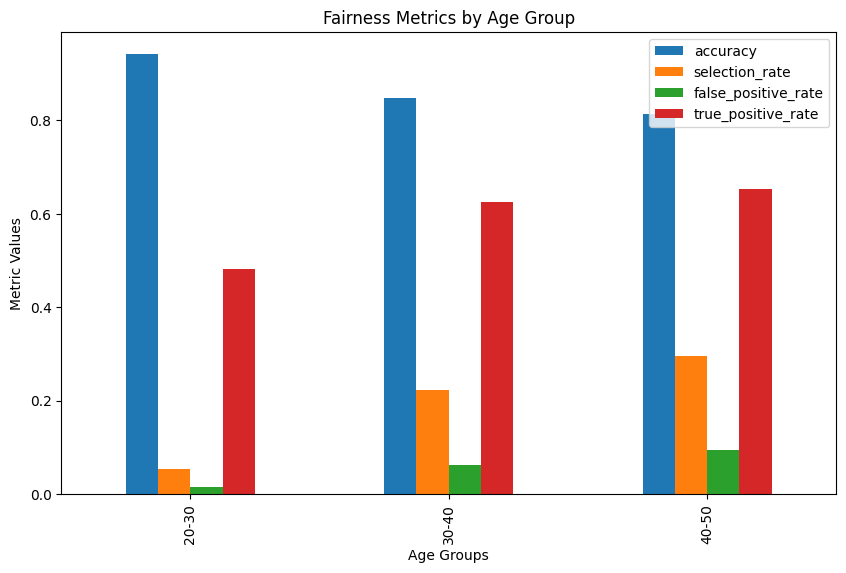

In [ ]:
# 3. Fairness Analysis using Fairlearn
# Create a MetricFrame to compute fairness metrics by group
metric_frame = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate,
        'false_positive_rate': false_positive_rate,
        'true_positive_rate': true_positive_rate
    },
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=sensitive_feature[X_test.index]
)
print(metric_frame.by_group)
metric_frame.by_group.plot(kind='bar', figsize=(10, 6))
plt.title("Fairness Metrics by Age Group")
plt.ylabel("Metric Values")
plt.xlabel("Age Groups")
plt.show()

##The fairness metrics show that the model performs best for the 20-30 age group, with high accuracy and very low false positive rates. However, as age increases, the model becomes less reliable: both the 30-40 and 40-50 groups experience higher false positive rates and higher selection rates, meaning the model makes more incorrect positive predictions for them. In conclusion, the model is significantly more accurate and fairer for younger users, while older groups face reduced performance and increased error rates, indicating a fairness imbalance that needs attention.


In [ ]:
# 4. Explainability Analysis
# SHAP Analysis
explainer = shap.Explainer(model.predict, X_test)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

PermutationExplainer explainer:   5%|▌         | 326/6513 [40:58<12:54:24,  7.51s/it]

In [ ]:
# LIME Analysis
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X.columns,
    class_names=['young', 'old'],
    mode='classification'
)
exp = explainer.explain_instance(X_test.iloc[0], model.predict_proba)
exp.show_in_notebook(show_table=True)

In [ ]:
# 5. Save Model
joblib.dump(model, 'fairness_model_v1.pkl')

# Example Application Discussion
example_application = "This model can be deployed in healthcare systems for diabetes prediction, ensuring fairness and transparency. Bias mitigation techniques should be integrated to avoid discrimination against specific age groups."